# Visualize dữ liệu train + output đã train

Notebook này trực quan hóa kết hợp:
- Dữ liệu lịch sử train (`sales.csv`)
- Kết quả dự báo đã train (`submission.csv`)
- Metrics và CV từ `baseline_metrics.json`

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 130
plt.rcParams['figure.figsize'] = (13, 5)

In [2]:
ROOT = Path('..').resolve()
RAW_DIR = ROOT / 'data' / 'raw'
PROCESSED_DIR = ROOT / 'data' / 'processed'

sales_path = (PROCESSED_DIR / 'sales.csv') if (PROCESSED_DIR / 'sales.csv').exists() else (RAW_DIR / 'sales.csv')
submission_path = PROCESSED_DIR / 'submission.csv'
metrics_path = PROCESSED_DIR / 'baseline_metrics.json'

print('sales_path     :', sales_path)
print('submission_path:', submission_path)
print('metrics_path   :', metrics_path)

if not submission_path.exists():
    raise FileNotFoundError('Không thấy submission.csv. Hãy chạy train trước.')
if not metrics_path.exists():
    raise FileNotFoundError('Không thấy baseline_metrics.json. Hãy chạy train trước.')

sales_path     : D:\Pancake-Utopia\GitHub\datathon-hkbaleycb4\data\processed\sales.csv
submission_path: D:\Pancake-Utopia\GitHub\datathon-hkbaleycb4\data\processed\submission.csv
metrics_path   : D:\Pancake-Utopia\GitHub\datathon-hkbaleycb4\data\processed\baseline_metrics.json


In [3]:
sales = pd.read_csv(sales_path, low_memory=False)
sales['Date'] = pd.to_datetime(sales['Date'], errors='coerce')
sales['Revenue'] = pd.to_numeric(sales['Revenue'], errors='coerce')
sales['COGS'] = pd.to_numeric(sales['COGS'], errors='coerce') if 'COGS' in sales.columns else np.nan
sales = sales.dropna(subset=['Date', 'Revenue']).sort_values('Date').reset_index(drop=True)

submission = pd.read_csv(submission_path, low_memory=False)
submission['Date'] = pd.to_datetime(submission['Date'], errors='coerce')
submission['Revenue'] = pd.to_numeric(submission['Revenue'], errors='coerce')
submission['COGS'] = pd.to_numeric(submission['COGS'], errors='coerce') if 'COGS' in submission.columns else np.nan
submission = submission.dropna(subset=['Date', 'Revenue']).sort_values('Date').reset_index(drop=True)

metrics = json.loads(metrics_path.read_text(encoding='utf-8'))

print('Train shape     :', sales.shape)
print('Submission shape:', submission.shape)
print('Selected method :', metrics.get('selected_method'))
print('Selected metrics:', metrics.get('selected_metrics'))
display(sales.head(3))
display(submission.head(3))

Train shape     : (3833, 3)
Submission shape: (548, 3)
Selected method : lightgbm
Selected metrics: {'mae': 1190640.2885423428, 'rmse': 1642781.567417789, 'r2': 0.4111210470564379}


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84


,Date,Revenue,COGS
0,2023-01-01,2.036635e+06,1.781255e+06
1,2023-01-02,2.098720e+06,1.835555e+06
2,2023-01-03,2.013654e+06,1.761156e+06


## 1) Revenue: lịch sử train + dự báo output

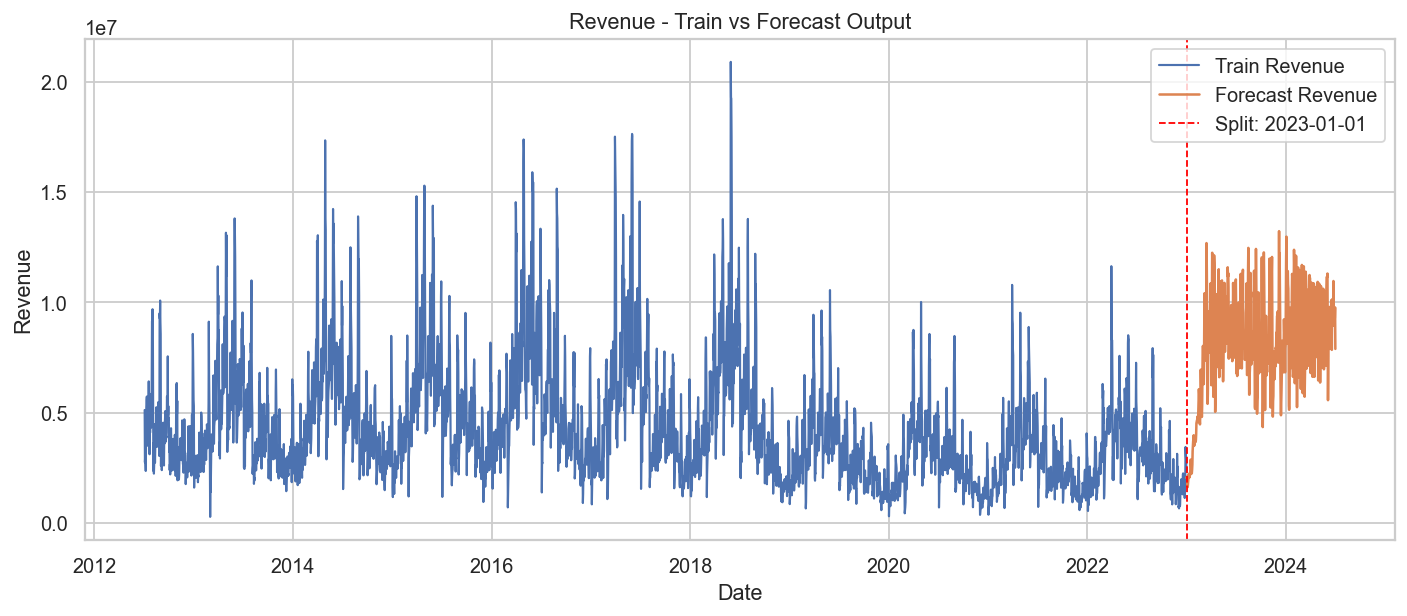

In [4]:
split_date = submission['Date'].min()

fig, ax = plt.subplots()
ax.plot(sales['Date'], sales['Revenue'], label='Train Revenue', linewidth=1.2)
ax.plot(submission['Date'], submission['Revenue'], label='Forecast Revenue', linewidth=1.4)
ax.axvline(split_date, color='red', linestyle='--', linewidth=1, label=f'Split: {split_date.date()}')
ax.set_title('Revenue - Train vs Forecast Output')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.show()

## 2) COGS: lịch sử train + dự báo output

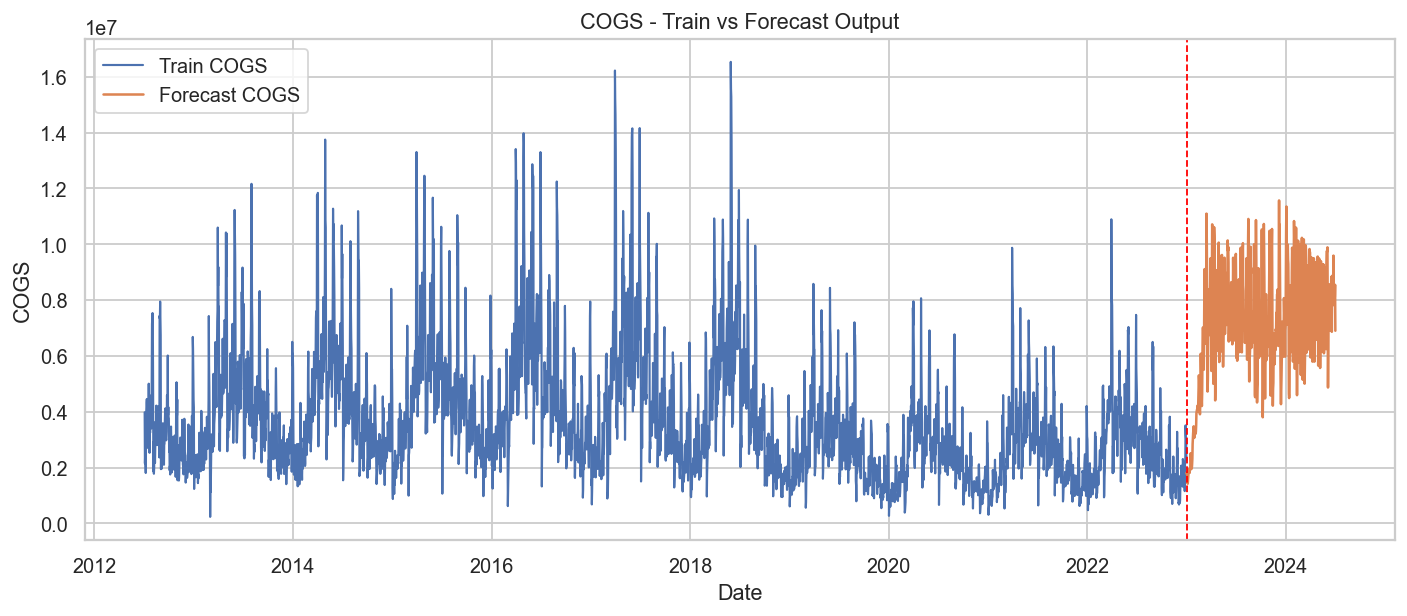

In [5]:
fig, ax = plt.subplots()
if sales['COGS'].notna().any():
    ax.plot(sales['Date'], sales['COGS'], label='Train COGS', linewidth=1.2)
ax.plot(submission['Date'], submission['COGS'], label='Forecast COGS', linewidth=1.4)
ax.axvline(split_date, color='red', linestyle='--', linewidth=1)
ax.set_title('COGS - Train vs Forecast Output')
ax.set_xlabel('Date')
ax.set_ylabel('COGS')
ax.legend()
plt.show()

## 3) Zoom vùng chuyển tiếp (đuôi train + đầu forecast)

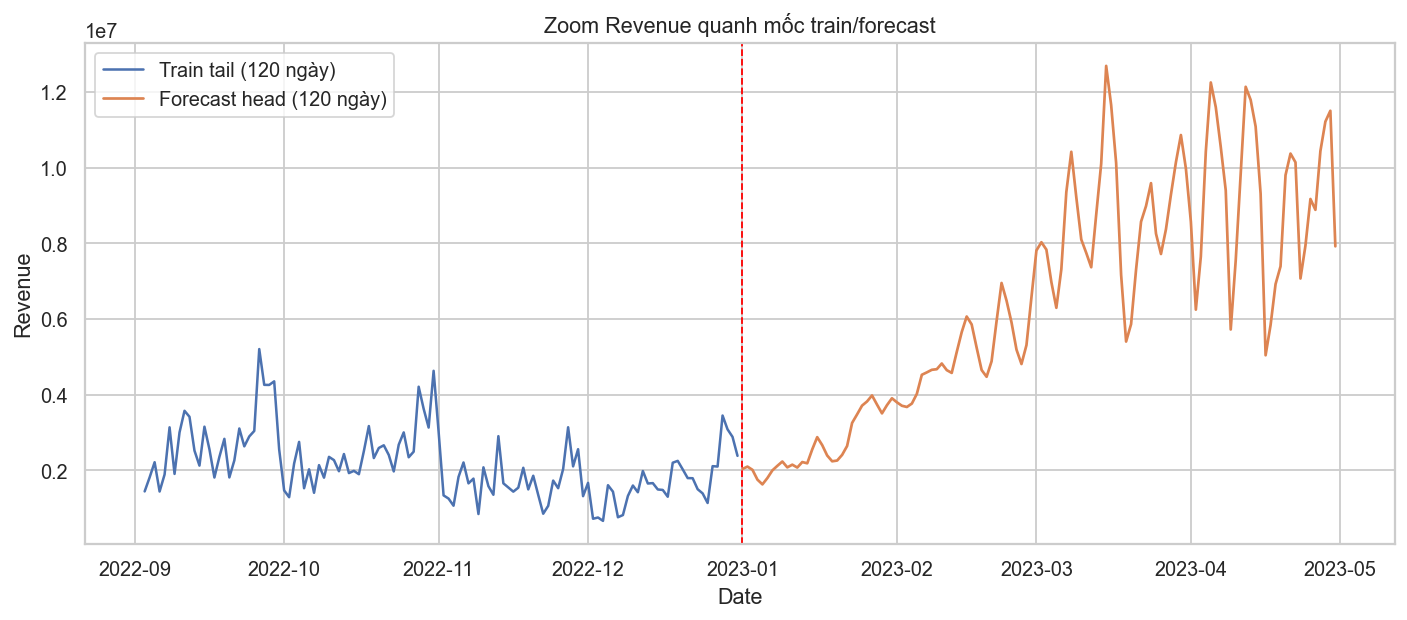

In [6]:
tail_days = 120
head_days = min(120, len(submission))

sales_tail = sales.tail(tail_days).copy()
submission_head = submission.head(head_days).copy()

fig, ax = plt.subplots()
ax.plot(sales_tail['Date'], sales_tail['Revenue'], label=f'Train tail ({tail_days} ngày)', linewidth=1.4)
ax.plot(submission_head['Date'], submission_head['Revenue'], label=f'Forecast head ({head_days} ngày)', linewidth=1.5)
ax.axvline(split_date, color='red', linestyle='--', linewidth=1)
ax.set_title('Zoom Revenue quanh mốc train/forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue')
ax.legend()
plt.show()

## 4) So sánh CV metrics giữa các model

,model,mae,rmse,r2
0,lightgbm,1.190640e+06,1.642782e+06,0.411121
1,seasonal_naive,2.632389e+06,3.237935e+06,-3.189479
2,linear_regression,6.631123e+06,6.923128e+06,-118.355155


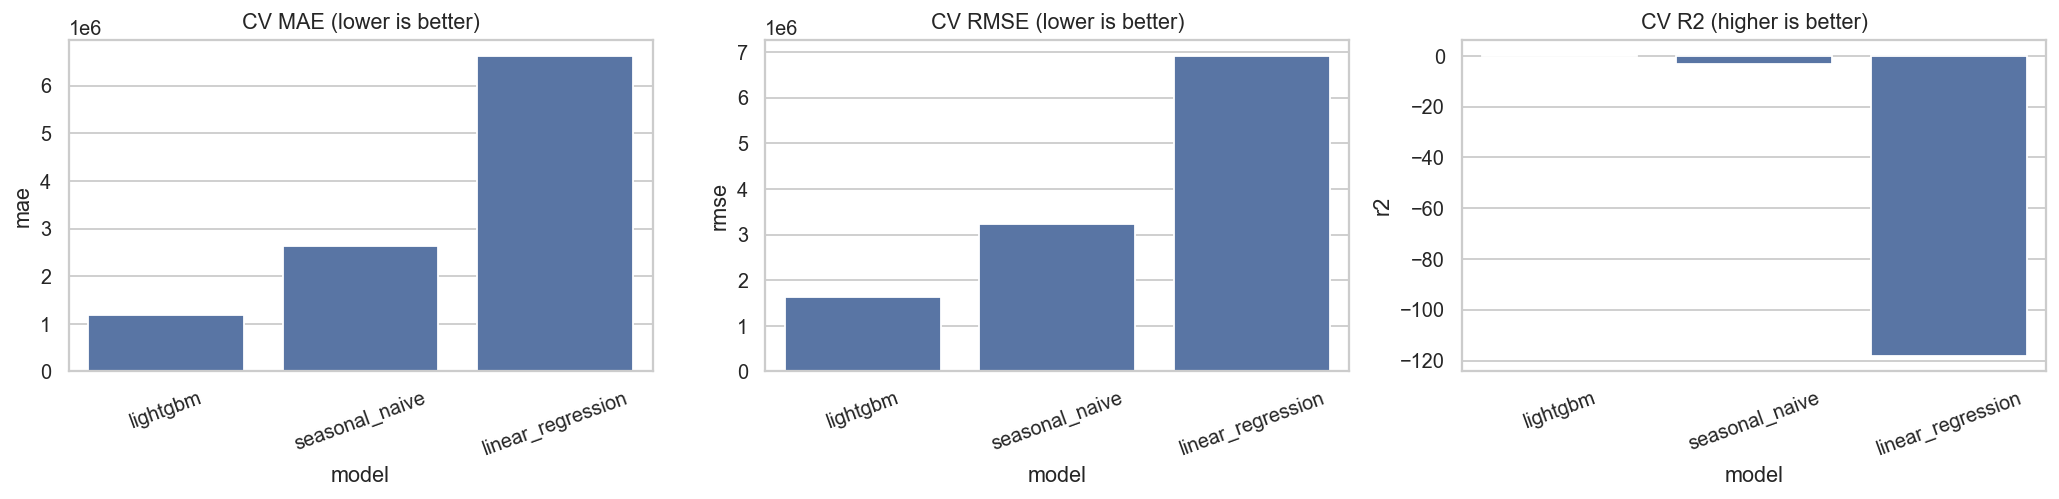

In [7]:
rows = []
for model_name, payload in metrics.get('cv', {}).get('results', {}).items():
    avg = payload.get('avg_metrics', {})
    rows.append(
        {
            'model': model_name,
            'mae': avg.get('mae', np.nan),
            'rmse': avg.get('rmse', np.nan),
            'r2': avg.get('r2', np.nan),
        }
    )

cv_df = pd.DataFrame(rows).sort_values('mae').reset_index(drop=True)
display(cv_df)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.barplot(data=cv_df, x='model', y='mae', ax=axes[0])
axes[0].set_title('CV MAE (lower is better)')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=cv_df, x='model', y='rmse', ax=axes[1])
axes[1].set_title('CV RMSE (lower is better)')
axes[1].tick_params(axis='x', rotation=20)

sns.barplot(data=cv_df, x='model', y='r2', ax=axes[2])
axes[2].set_title('CV R2 (higher is better)')
axes[2].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [8]:
selected_method = metrics.get('selected_method')
selected_metrics = metrics.get('selected_metrics', {})

summary = {
    'selected_method': selected_method,
    'mae': selected_metrics.get('mae'),
    'rmse': selected_metrics.get('rmse'),
    'r2': selected_metrics.get('r2'),
    'train_start': str(sales['Date'].min().date()),
    'train_end': str(sales['Date'].max().date()),
    'forecast_start': str(submission['Date'].min().date()),
    'forecast_end': str(submission['Date'].max().date()),
}
summary

{'selected_method': 'lightgbm',
 'mae': 1190640.2885423428,
 'rmse': 1642781.567417789,
 'r2': 0.4111210470564379,
 'train_start': '2012-07-04',
 'train_end': '2022-12-31',
 'forecast_start': '2023-01-01',
 'forecast_end': '2024-07-01'}